In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Import các thư viện cần thiết**

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from collections import Counter

In [3]:
# train_data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/ds/train.csv')
# test_data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/ds/test.csv')
train_data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/ds/cleaned_data_train.csv')
test_data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/ds/cleaned_data_test.csv')

In [4]:
print(train_data.head())

   temp_c  precip_mm  humidity  pressure_mb  wind_kph  cloud  dewpoint_c  \
0    24.5        0.1        83        999.0      10.8     86        21.5   
1    26.6        0.2        77       1014.0       4.3     83        22.4   
2    17.2        0.0        92       1013.0       9.4     15        15.9   
3    20.9        0.0        72       1017.0       3.2     20        15.7   
4    26.1        0.0        86       1006.0       9.0     12        23.6   

   feelslike_c  vis_km  gust_kph             condition  dewpoint_depression  \
0         26.6    10.0      14.1  Patchy rain possible                  3.0   
1         29.3    10.0       5.3  Patchy rain possible                  4.2   
2         19.2    10.0      12.7                 Clear                  1.3   
3         22.9    10.0       8.9                 Sunny                  5.2   
4         29.3    10.0      11.2                 Clear                  2.5   

   hour  condition_encoded  
0     1                  0  
1     8   

**Các features đã được chọn ở phần feature engineer**

In [5]:
features = ['cloud', 'precip_mm', 'hour', 'pressure_mb', 'humidity', 'dewpoint_c', 'dewpoint_depression']
target = 'condition'

In [6]:
X_train = train_data[features]
y_train = train_data[target]
X_test = test_data[features]
y_test = test_data[target]

In [7]:
labels = [
    "Clear", "Cloudy", "Heavy rain at times", "Light rain shower",
    "Moderate or heavy rain shower", "Moderate rain at times", "Overcast",
    "Partly cloudy", "Patchy light rain with thunder", "Patchy rain possible",
    "Sunny"
]

## Chọn mô hình phân lớp với Nested Cross-Validation

Hàm `lua_chon_mo_hinh_phan_lop` được sử dụng để lựa chọn mô hình phân lớp tối ưu bằng phương pháp **Nested Cross-Validation** kết hợp với **GridSearchCV**. Mục tiêu là đánh giá hiệu suất thực sự của mô hình sau khi tìm được siêu tham số tối ưu, từ đó tránh được tình trạng overfitting khi chọn siêu tham số.

### Outer Loop (outer_cv):
Chia dữ liệu thành 5 phần (5-fold). Mỗi vòng lặp sẽ giữ lại 1 phần làm tập kiểm tra bên ngoài (outer test), 4 phần còn lại dùng để huấn luyện và chọn siêu tham số.
Mục tiêu: Đánh giá chính xác hiệu suất mô hình cuối cùng.

### Inner Loop (inner_cv):
Với 4 phần của outer training set, tiếp tục chia thành 3 phần để huấn luyện và validate. Dùng để tìm tổ hợp siêu tham số tốt nhất.

### GridSearchCV:
GridSearchCV là công cụ tìm kiếm tổ hợp siêu tham số tốt nhất thông qua việc thử toàn bộ các cấu hình trong param_grid. Với mỗi cấu hình, mô hình sẽ được huấn luyện nhiều lần theo số fold của inner_cv, sau đó chọn ra mô hình có độ chính xác (accuracy) cao nhất.

1. estimator: Mô hình cơ sở (VD: RandomForestClassifier, MLPClassifier)

2. param_grid: Tập hợp các siêu tham số cần thử

3. scoring='accuracy': Tiêu chí đánh giá mô hình là độ chính xác

4. n_jobs=-1: Tận dụng tối đa CPU để tăng tốc tính toán

### Hàm mất mát - Cross Entropy Loss:

$$ {Loss} = -\frac{1}{n} \sum_{i=1}^{n} \left[ y_i \cdot \log(\hat{y}_i) + (1 - y_i) \cdot \log(1 - \hat{y}_i) \right] $$

In [8]:
def lua_chon_mo_hinh_phan_lop(X, y, param_grid, base_model):
    # Outer loop: đánh giá tổng thể mô hình
    outer_cv = KFold(n_splits=5, shuffle=True, random_state=42)

    # Inner loop: chọn siêu tham số
    inner_cv = KFold(n_splits=3, shuffle=True, random_state=1)

    accuracy_scores = []
    all_best_params = []

    fold = 1
    for train_idx, val_idx in outer_cv.split(X):
        print(f'\n----- Fold {fold} -----')

        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        # GridSearchCV với accuracy
        grid_search = GridSearchCV(
            estimator=base_model,
            param_grid=param_grid,
            cv=inner_cv,
            scoring='accuracy',  # sử dụng accuracy
            n_jobs=-1,
            verbose=0
        )
        grid_search.fit(X_train, y_train)
        best_model = grid_search.best_estimator_
        all_best_params.append(grid_search.best_params_)

        print("Best parameters:", grid_search.best_params_)

        y_pred = best_model.predict(X_val)

        acc = accuracy_score(y_val, y_pred)
        print(f'Accuracy: {acc:.4f}')

        accuracy_scores.append(acc)
        fold += 1

    print('\n====== Kết quả trung bình sau 5 fold ======')
    mean_acc = np.mean(accuracy_scores)
    print(f'Accuracy trung bình: {mean_acc:.4f}')

    most_common_params = Counter(tuple(sorted(p.items())) for p in all_best_params).most_common(1)[0][0]

    best_params = dict(most_common_params)
    return best_params

## Huấn luyện và đánh giá mô hình phân lớp Random Forest

Huấn luyện mô hình Random Forest + GridSearch. Sử dụng `RandomForestClassifier` làm mô hình cơ sở, kết hợp với `GridSearchCV` để tìm ra tổ hợp siêu tham số tốt nhất qua hàm `lua_chon_mo_hinh_phan_lop`


In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Mô hình phân lớp + GridSearch
base_model = RandomForestClassifier(random_state=42)
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10]
}

# Hàm chọn mô hình dùng accuracy (đã viết ở trên)
best_params = lua_chon_mo_hinh_phan_lop(X_train, y_train, param_grid, base_model)


----- Fold 1 -----
Best parameters: {'max_depth': 10, 'n_estimators': 100}
Accuracy: 0.9793

----- Fold 2 -----
Best parameters: {'max_depth': None, 'n_estimators': 200}
Accuracy: 0.9776

----- Fold 3 -----
Best parameters: {'max_depth': 10, 'n_estimators': 200}
Accuracy: 0.9735

----- Fold 4 -----
Best parameters: {'max_depth': None, 'n_estimators': 200}
Accuracy: 0.9793

----- Fold 5 -----
Best parameters: {'max_depth': None, 'n_estimators': 200}
Accuracy: 0.9784

====== Kết quả trung bình sau 5 fold ======
Accuracy trung bình: 0.9776


In [10]:
print(f'siêu tham số tốt nhất: {best_params}')

siêu tham số tốt nhất: {'max_depth': None, 'n_estimators': 200}


## các siêu tham số trong mô hình Random Forest Classifier

1. n_estimators = 200: Là số lượng cây (decision trees) trong rừng ngẫu nhiên.
2. max_depth = None: giới hạn độ sâu tối đa của mỗi cây.


In [11]:
# Huấn luyện mô hình tốt nhất
rf_model = RandomForestClassifier(**best_params, random_state=42)
rf_model.fit(X_train_scaled, y_train)
rf_train_acc_score = rf_model.score(X_train_scaled, y_train)

# Dự đoán và đánh giá trên test set
y_test_pred = rf_model.predict(X_test_scaled)

print("\n=== Đánh giá trên Test Set ===")
rf_acc_score = accuracy_score(y_test, y_test_pred)
print(f"Test Accuracy: {rf_acc_score:.4f}")
rf_conf_matrix = confusion_matrix(y_test, y_test_pred)
print("\nClassification Report (Test):")
rf_class_report = classification_report(y_test, y_test_pred)
print(rf_class_report)


=== Đánh giá trên Test Set ===
Test Accuracy: 0.9814

Classification Report (Test):
                                precision    recall  f1-score   support

                         Clear       0.97      0.98      0.97       194
                        Cloudy       1.00      0.99      0.99       218
           Heavy rain at times       0.92      0.95      0.94        38
             Light rain shower       1.00      0.12      0.22         8
 Moderate or heavy rain shower       0.94      1.00      0.97        83
        Moderate rain at times       0.98      1.00      0.99        95
                      Overcast       0.98      0.99      0.99       188
                 Partly cloudy       0.99      0.99      0.99       212
Patchy light rain with thunder       0.00      0.00      0.00         1
          Patchy rain possible       1.00      1.00      1.00       328
                         Sunny       0.96      0.96      0.96       143

                      accuracy                   

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Mô hình hóa kết quả trên tập test


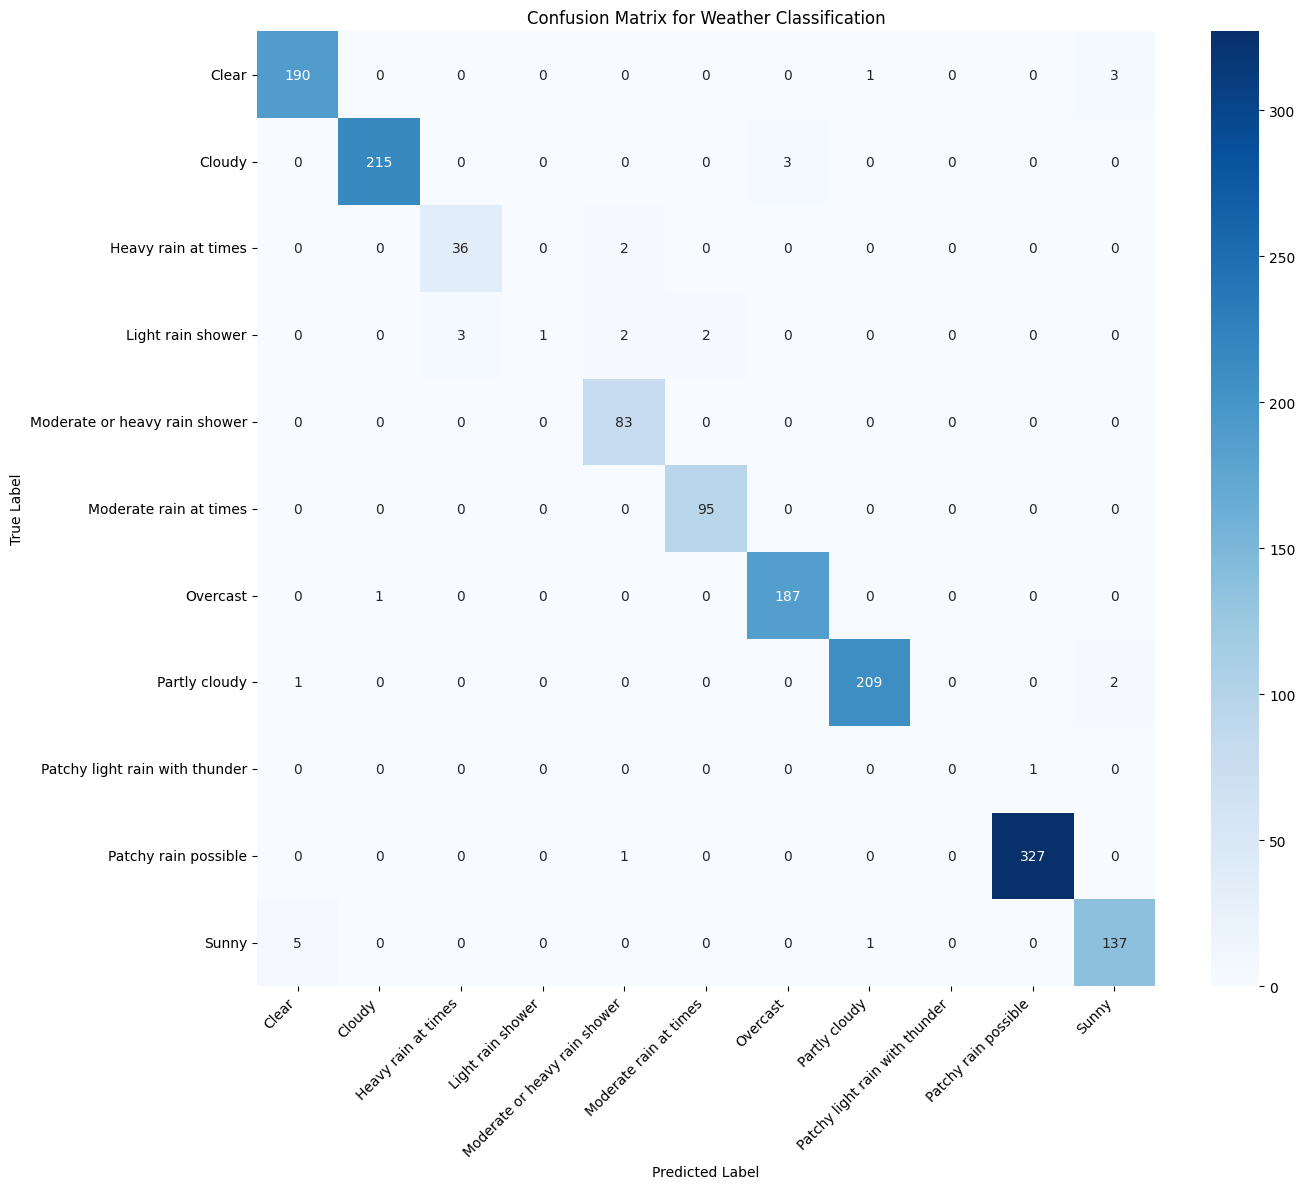

In [ ]:
# Plot confusion matrix
plt.figure(figsize=(14, 12))
sns.heatmap(rf_conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix for Weather Classification")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Tìm siêu tham số, huấn luyện và đánh giá mô hình MLPClassifier

Huấn luyện mô hình MLPClassifier + GridSearch. Sử dụng `MLPClassifier` làm mô hình cơ sở, kết hợp với `GridSearchCV` để tìm ra tổ hợp siêu tham số tốt nhất qua hàm `lua_chon_mo_hinh_phan_lop`

In [12]:
base_model = MLPClassifier(random_state=42, max_iter=200)

# Grid các siêu tham số cho MLPClassifier
param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50)],
    'activation': ['relu', 'tanh'],
    'learning_rate_init': [0.001, 0.01],
    'alpha': [0.0001, 0.001]
}

# Tìm siêu tham số tốt nhất (hàm lua_chon_mo_hinh_phan_lop đã sửa ở trên)
best_params = lua_chon_mo_hinh_phan_lop(X_train, y_train, param_grid, base_model)


----- Fold 1 -----
Best parameters: {'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (50, 50), 'learning_rate_init': 0.01}
Accuracy: 0.7595

----- Fold 2 -----
Best parameters: {'activation': 'tanh', 'alpha': 0.001, 'hidden_layer_sizes': (50, 50), 'learning_rate_init': 0.001}
Accuracy: 0.8715

----- Fold 3 -----
Best parameters: {'activation': 'tanh', 'alpha': 0.0001, 'hidden_layer_sizes': (50, 50), 'learning_rate_init': 0.001}
Accuracy: 0.8051

----- Fold 4 -----


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Best parameters: {'activation': 'tanh', 'alpha': 0.001, 'hidden_layer_sizes': (100,), 'learning_rate_init': 0.001}
Accuracy: 0.8415

----- Fold 5 -----
Best parameters: {'activation': 'tanh', 'alpha': 0.001, 'hidden_layer_sizes': (100,), 'learning_rate_init': 0.001}
Accuracy: 0.8108

====== Kết quả trung bình sau 5 fold ======
Accuracy trung bình: 0.8177


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
print(f'siêu tham số tốt nhất: {best_params}')

siêu tham số tốt nhất: {'activation': 'tanh', 'alpha': 0.001, 'hidden_layer_sizes': (100,), 'learning_rate_init': 0.001}


## các siêu tham số trong mô hình MLP Classifier

1. activation = 'tanh': hàm kích hoạt.
2. alpha = 0.001: Hệ số regularization L2 (weight decay).
3. hidden_layer_sizes = (100,): Mạng có 1 hidden layer với 100 neuron.
4. learning_rate_init = 0.001: tốc độ học.
5. max_iter = 200: số lần lặp.


In [ ]:
# Huấn luyện mô hình với tham số tối ưu
mlp_model = MLPClassifier(**best_params, random_state=42, max_iter=200)
mlp_model.fit(X_train_scaled, y_train)
mlp_train_acc_score = mlp_model.score(X_train_scaled, y_train)

# Dự đoán và đánh giá
y_test_pred = mlp_model.predict(X_test_scaled)

print("\n=== Đánh giá trên Test Set ===")
mlp_acc_score = accuracy_score(y_test, y_test_pred)
print(f"Test Accuracy: {mlp_acc_score:.4f}")
print("Confusion Matrix (Test):")
mlp_conf_matrix = confusion_matrix(y_test, y_test_pred)
print(mlp_conf_matrix)
print("\nClassification Report:")
mlp_class_report = classification_report(y_test, y_test_pred)
print(mlp_class_report)


=== Đánh giá trên Test Set ===
Test Accuracy: 0.9735
Confusion Matrix (Test):
[[187   0   0   0   0   0   0   3   0   0   4]
 [  0 216   0   0   0   0   2   0   0   0   0]
 [  0   0  35   0   1   2   0   0   0   0   0]
 [  0   0   3   0   2   2   0   0   0   1   0]
 [  0   0   0   0  83   0   0   0   0   0   0]
 [  0   0   0   0   0  95   0   0   0   0   0]
 [  0   3   0   0   0   0 185   0   0   0   0]
 [  1   0   0   0   0   0   0 211   0   0   0]
 [  0   0   0   0   0   0   0   0   0   1   0]
 [  0   2   0   0   1   0   2   0   0 323   0]
 [  8   0   0   0   0   0   0   2   0   0 133]]

Classification Report:
                                precision    recall  f1-score   support

                         Clear       0.95      0.96      0.96       194
                        Cloudy       0.98      0.99      0.98       218
           Heavy rain at times       0.92      0.92      0.92        38
             Light rain shower       0.00      0.00      0.00         8
 Moderate or heavy

/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and bei

## Biểu đồ loss của mô hình MLP

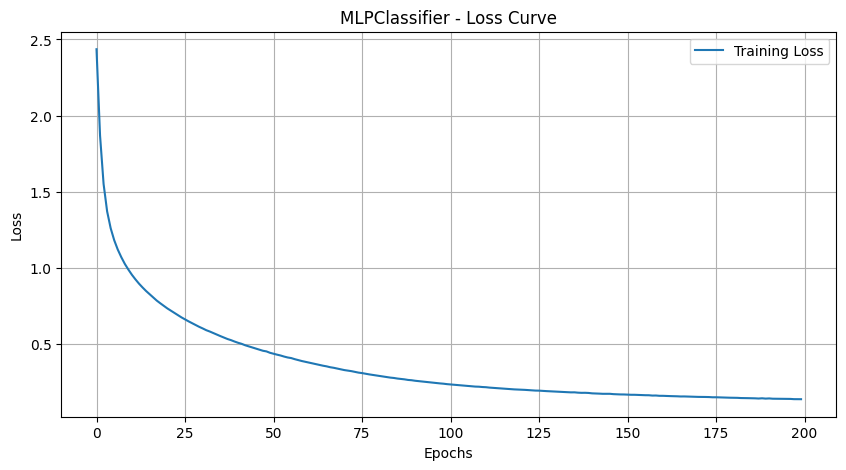

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(mlp_model.loss_curve_, label="Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("MLPClassifier - Loss Curve")
plt.grid(True)
plt.legend()
plt.show()

## Mô hình hóa kết quả trên tập test


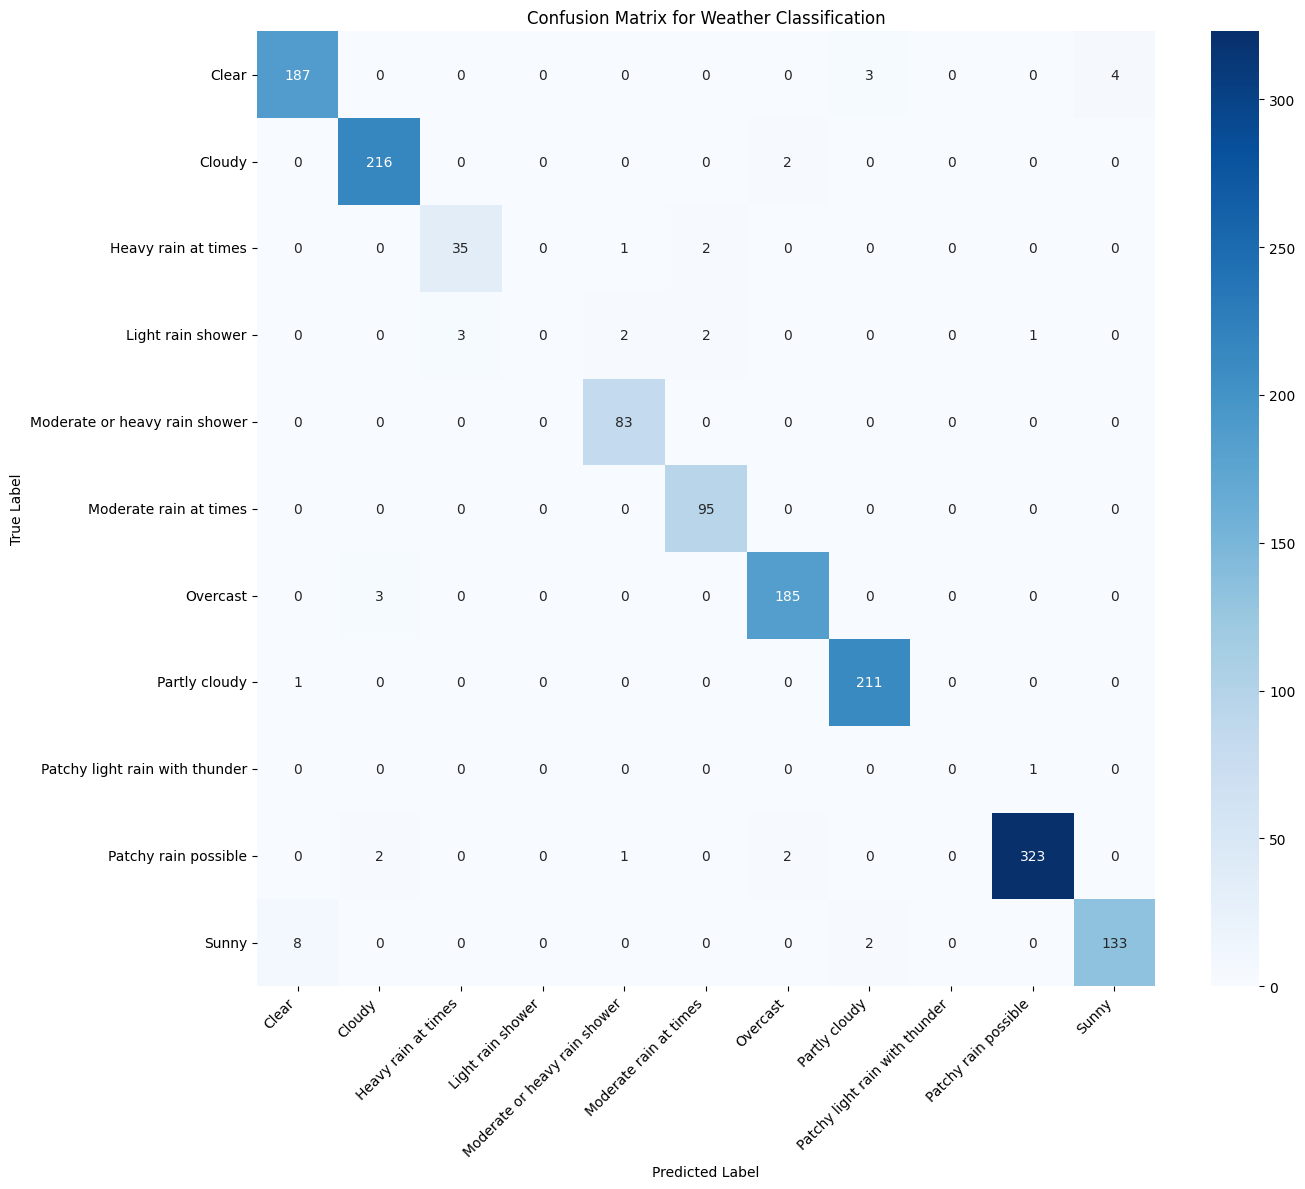

In [ ]:
# Plot confusion matrix
plt.figure(figsize=(14, 12))
sns.heatmap(mlp_conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix for Weather Classification")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

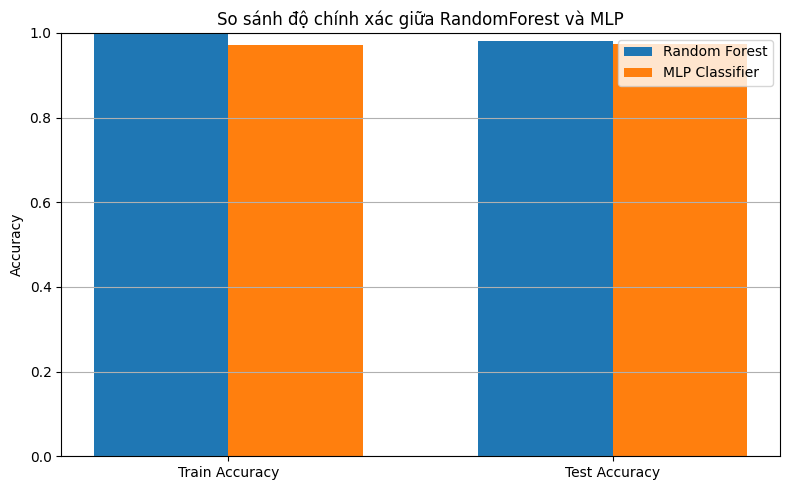

In [ ]:
labels = ['Train Accuracy', 'Test Accuracy']
rf_scores = [rf_train_acc_score, rf_acc_score]
mlp_scores = [mlp_train_acc_score, mlp_acc_score]

x = np.arange(len(labels))  # [0, 1]
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, rf_scores, width, label='Random Forest')
plt.bar(x + width/2, mlp_scores, width, label='MLP Classifier')

plt.ylabel('Accuracy')
plt.title('So sánh độ chính xác giữa RandomForest và MLP')
plt.xticks(x, labels)
plt.ylim(0, 1.0)
plt.legend()
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()